<a href="https://colab.research.google.com/github/sreenidhi2545/Chameleon-vs-K-means/blob/main/DataMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload your CSV


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Saving archive.zip to archive.zip
 File uploaded: archive.zip
CSV 'flipkart_com-ecommerce_sample.csv' extracted from ZIP and loaded.
Dataset Loaded. Shape: (20000, 15)
After Cleaning: (14070, 5)
Final Feature Vector Shape: (14070, 3787)
PCA Reduced Shape: (14070, 15)
Chameleon Cluster Labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38]

Silhouette Scores:
K-Means: 0.31889901638710927
Chameleon (HDBSCAN): 0.7108085034360805


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


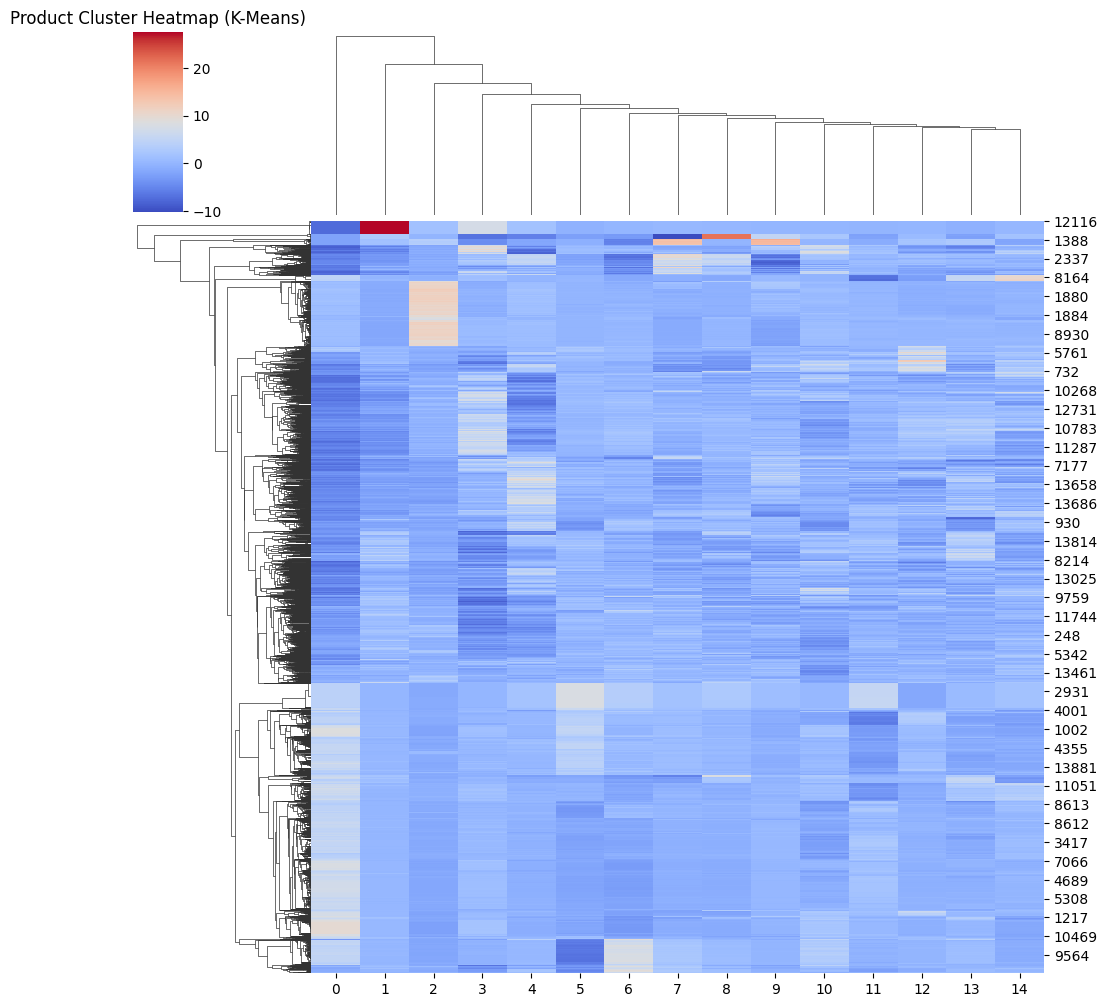

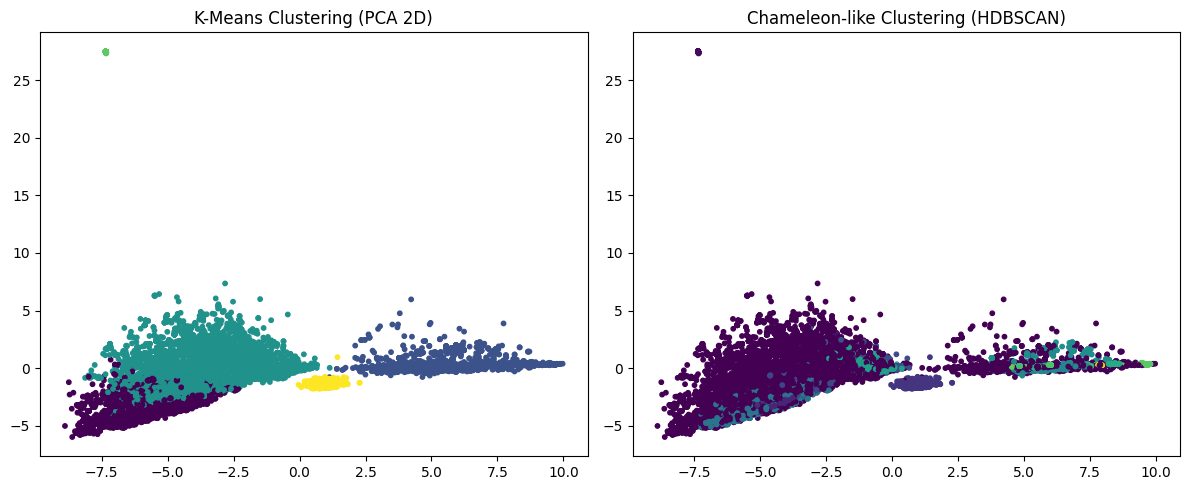


-------- FINAL SUMMARY --------
K-Means Silhouette: 0.3189
Chameleon Silhouette: 0.7108
Conclusion: Chameleon-like clustering performed better.


In [1]:
import numpy as np
import pandas as pd
import io
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
import hdbscan
from google.colab import files
import zipfile

# FILE UPLOAD
print("Please upload your CSV")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(" File uploaded:", filename)

if filename.endswith('.zip'):
    with zipfile.ZipFile(io.BytesIO(uploaded[filename]), 'r') as zf:
        csv_filename = [name for name in zf.namelist() if name.endswith('.csv')][0]
        with zf.open(csv_filename) as csv_file:
            df = pd.read_csv(csv_file, encoding='latin1')
    print(f"CSV '{csv_filename}' extracted from ZIP and loaded.")
else:
    # load the CSV directly
    df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='latin1')

print("Dataset Loaded. Shape:", df.shape)

columns_needed = ['product_category_tree',
                  'retail_price',
                  'discounted_price',
                  'brand',
                  'description']

df_use = df[columns_needed].copy()
df_use.dropna(inplace=True)

print("After Cleaning:", df_use.shape)
# NUMERIC FEATURES
num_features = df_use[['retail_price', 'discounted_price']].astype(float)

# ONE-HOT ENCODING
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
brand_encoded = ohe.fit_transform(df_use[['brand']])

# TEXT FEATURES
tfidf = TfidfVectorizer(max_features=300)
text_vec = tfidf.fit_transform(df_use['description'].astype(str)).toarray()


# COMBINE FEATURES
X = np.hstack([num_features, brand_encoded, text_vec])
print("Final Feature Vector Shape:", X.shape)


# SCALING + PCA
scaler = StandardScaler()
scaled = scaler.fit_transform(X)

pca = PCA(n_components=15)
reduced = pca.fit_transform(scaled)

print("PCA Reduced Shape:", reduced.shape)


# CHAMELEON-LIKE CLUSTERING (HDBSCAN)
cham = hdbscan.HDBSCAN(min_cluster_size=40, metric='euclidean')
labels_cham = cham.fit_predict(reduced)

print("Chameleon Cluster Labels:", np.unique(labels_cham))
# silhouette
unique_cham = np.unique(labels_cham)
if len(unique_cham) > 1 and not (len(unique_cham) == 1 and unique_cham[0] == -1):
    mask = labels_cham != -1
    sil_cham = silhouette_score(reduced[mask], labels_cham[mask])
else:
    sil_cham = 0.0
# K-MEANS CLUSTERING
kmeans = KMeans(n_clusters=5, random_state=42)
labels_km = kmeans.fit_predict(reduced)

sil_km = silhouette_score(reduced, labels_km)
#SILHOUETTE SCORES
print("\nSilhouette Scores:")
print("K-Means:", sil_km)
print("Chameleon (HDBSCAN):", sil_cham)
# HEATMAP (K-MEANS)
df_heat = pd.DataFrame(reduced)
df_heat["cluster"] = labels_km

sns.clustermap(df_heat.iloc[:, :-1], cmap="coolwarm")
plt.title("Product Cluster Heatmap (K-Means)")
plt.show()
# 10) SCATTER PLOTS
plt.figure(figsize=(12, 5))

# K-MEANS
plt.subplot(1, 2, 1)
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels_km, s=10)
plt.title("K-Means Clustering (PCA 2D)")

# CHAMELEON
plt.subplot(1, 2, 2)
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels_cham, s=10)
plt.title("Chameleon-like Clustering (HDBSCAN)")
plt.tight_layout()
plt.show()

print("\n-------- FINAL SUMMARY --------")
print(f"K-Means Silhouette: {sil_km:.4f}")
print(f"Chameleon Silhouette: {sil_cham:.4f}")

if sil_km > sil_cham:
    print("Conclusion: K-Means produced more well-defined clusters.")
else:
    print("Conclusion: Chameleon-like clustering performed better.")
